In [2]:
import pandas as pd
data = pd.read_csv("https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv")
data.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [8]:
print(data.columns)

Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type'],
      dtype='object')


In [9]:
import pandas as pd

neighborhood_avg = data.groupby('Neighbourhood ').agg(
    avg_price=('Price', 'mean'),
    avg_score=('Review Scores Rating', 'mean')
).sort_values(by='avg_price', ascending=False)

print(neighborhood_avg.head())


                 avg_price  avg_score
Neighbourhood                        
Manhattan       183.664286  91.801496
Staten Island   146.166667  90.843750
Brooklyn        127.747378  92.363497
Queens           96.857233  91.549057
Bronx            75.276498  91.654378


Manhattan is the most expensive borough on average. 

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

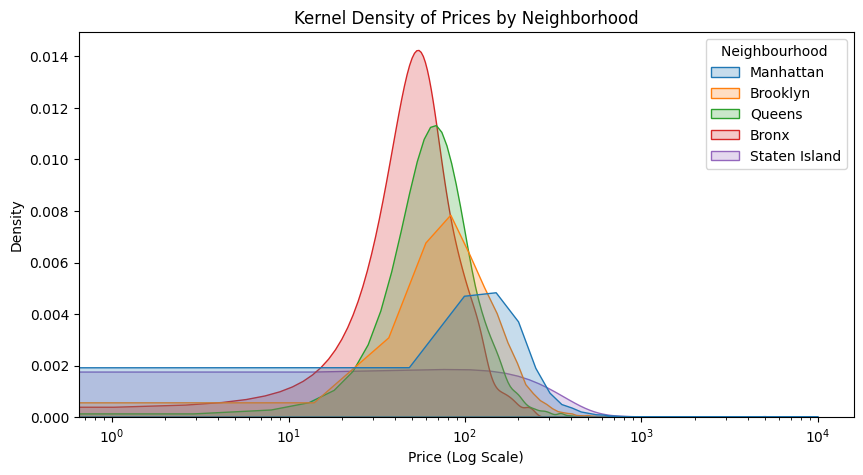

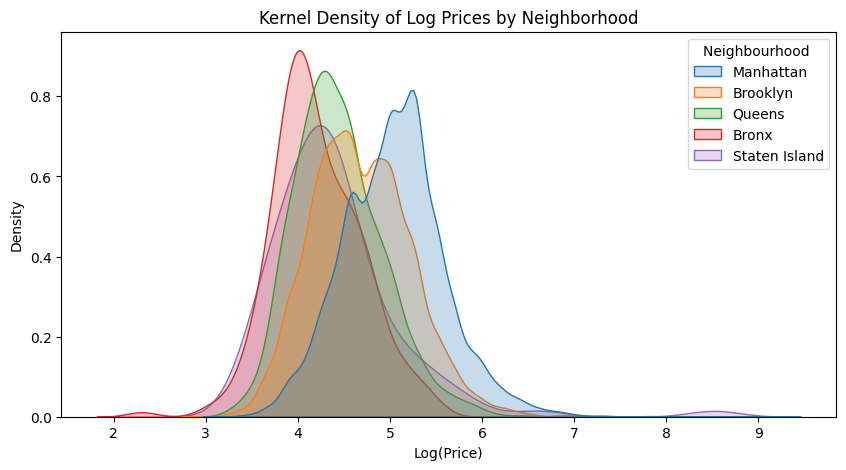

In [21]:
# Plot Kernel Density of Price (Log Scale)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=data, x='Price', hue='Neighbourhood ', common_norm=False, fill=True)
plt.xscale('log')  # Log scale for better visualization
plt.title("Kernel Density of Prices by Neighborhood")
plt.xlabel("Price (Log Scale)")
plt.ylabel("Density")
plt.show()

# Plot Kernel Density of Log Price
plt.figure(figsize=(10, 5))
sns.kdeplot(data=data, x=np.log(data['Price']), hue='Neighbourhood ', common_norm=False, fill=True)
plt.title("Kernel Density of Log Prices by Neighborhood")
plt.xlabel("Log(Price)")
plt.ylabel("Density")
plt.show()

In [23]:
import statsmodels.api as sm

In [24]:
# One-hot encode 'Neighborhood' without an intercept
data_encoded = pd.get_dummies(data, columns=['Neighbourhood '], drop_first=False)

# Define independent variables (all one-hot encoded Neighborhood columns)
X = data_encoded.filter(like='Neighbourhood ')

# Define dependent variable (Price)
y = data['Price']

# Run linear regression without intercept
model = sm.OLS(y, X).fit()

# Print summary of regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Mon, 24 Feb 2025   Prob (F-statistic):          4.43e-226
Time:                        03:59:49   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Neighbourhood _B

In [26]:
avg_neighborhood = data.groupby('Neighbourhood ')['Price'].mean()
print(avg_neighborhood)

Neighbourhood 
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Name: Price, dtype: float64


Each coefficient in the regression matches the mean price of that neighborhood. This happens because we removed the intercept, so the model treats each neighborhood as its own separate baseline. 

In a regression without an intercept, the coefficient for each Neighborhood represents the average price in that neighborhood. This confirms that regressing a continuous variable (Price) on a categorical variable (Neighborhood) without an intercept reproduces group means.

In [29]:
# One-hot encode 'Neighborhood' but drop one category (avoid dummy variable trap)
data_encoded = pd.get_dummies(data, columns=['Neighbourhood '], drop_first=True)

# Define independent variables (all one-hot encoded Neighborhood columns)
X = data_encoded.filter(like='Neighbourhood ')

# Add intercept
X = sm.add_constant(X)

# Define dependent variable (Price)
y = data['Price']

# Run linear regression with intercept
model = sm.OLS(y, X).fit()

# Print summary of regression
print(model.summary())


ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).